In [1]:
!git clone https://github.com/JaehaKim97/SR4IR.git
%cd SR4IR

Cloning into 'SR4IR'...
remote: Enumerating objects: 367, done.
remote: Counting objects: 100% (367/367), done.
remote: Compressing objects: 100% (232/232), done.
remote: Total 367 (delta 154), reused 319 (delta 130), pack-reused 0 (from 0)
Receiving objects: 100% (367/367), 1.59 MiB | 21.95 MiB/s, done.
Resolving deltas: 100% (154/154), done.
/content/SR4IR


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!cp "/content/drive/MyDrive/archive.zip" /content/

In [5]:
!unzip -q /content/archive.zip

In [6]:
%cd /content/SR4IR

/content/SR4IR


In [7]:
!rm -rf datasets/StanfordCars

In [10]:
!ls -lh /content/archive.zip

-rw------- 1 root root 1.9G Mar 26 11:54 /content/archive.zip


In [11]:
!apt-get update -qq
!apt-get install -y p7zip-full

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
p7zip-full is already the newest version (16.02+dfsg-8).
0 upgraded, 0 newly installed, 0 to remove and 56 not upgraded.


In [12]:
!7z x "/content/archive.zip" -o/content/


7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.00GHz (50653),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan /content/                   1 file, 1960225373 bytes (1870 MiB)

Extracting archive: /content/archive.zip
 25% 4096 Open              --
Path = /content/archive.zip
Type = zip
Physical Size = 1960225373

  0%      1% 239 - car_data/car_data/test/Acura TSX Sedan 2012/05855.jpg                                                                  3% 477 - car_data/car_data/test/Audi 100 Sedan 1994/06767.jpg                                                               

In [13]:
!ls /content
!ls /content/car_data
!ls /content/car_data/car_data

anno_test.csv	archive.zip  drive	sample_data
anno_train.csv	car_data     names.csv	SR4IR
car_data
test  train


In [14]:
%cd /content/SR4IR

/content/SR4IR


In [15]:
!rm -rf datasets/StanfordCars

In [16]:
import shutil

shutil.copytree(
    "/content/car_data/car_data/train",
    "datasets/StanfordCars/train"
)

shutil.copytree(
    "/content/car_data/car_data/test",
    "datasets/StanfordCars/val"
)

print("Stanford Cars dataset ready for SR4IR ✅")

Stanford Cars dataset ready for SR4IR ✅


In [17]:
!ls datasets/StanfordCars/train | head
!ls "datasets/StanfordCars/train/Acura Integra Type R 2001" | head

Acura Integra Type R 2001
Acura RL Sedan 2012
Acura TL Sedan 2012
Acura TL Type-S 2008
Acura TSX Sedan 2012
Acura ZDX Hatchback 2012
AM General Hummer SUV 2000
Aston Martin V8 Vantage Convertible 2012
Aston Martin V8 Vantage Coupe 2012
Aston Martin Virage Convertible 2012
00198.jpg
00255.jpg
00308.jpg
00374.jpg
00878.jpg
00898.jpg
01010.jpg
01012.jpg
01255.jpg
01617.jpg


In [18]:
import yaml

cfg_path = "options/cls/StanfordCars/134_SR4IR_swinir_x4.yml"

cfg = yaml.safe_load(open(cfg_path))
cfg["test"]["batch_size"] = 8
cfg["num_threads"] = 2

yaml.dump(cfg, open(cfg_path,"w"))

print("Config updated ✅")

Config updated ✅


In [20]:
!pip install lpips

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 5.5 MB/s eta 0:00:00


In [21]:
!pip install ptflops

In [23]:
!unzip -o /content/cls_train.zip

Archive:  /content/cls_train.zip
  inflating: cls/121_S2T_edsr_x8/models/net_sr_latest.pth  
  inflating: cls/123_SwT_edsr_x8/models/net_sr_latest.pth  
  inflating: cls/122_T2S_edsr_x8/models/net_cls_latest.pth  
  inflating: cls/122_T2S_edsr_x8/models/net_sr_latest.pth  
  inflating: cls/124_SR4IR_edsr_x8/models/net_sr_latest.pth  
  inflating: cls/121_S2T_edsr_x8/models/net_cls_latest.pth  
  inflating: cls/100_H2T/models/net_cls_latest.pth  
  inflating: cls/123_SwT_edsr_x8/models/net_cls_latest.pth  
  inflating: cls/144_SR4IR_swinir_x8/models/net_cls_latest.pth  
  inflating: cls/134_SR4IR_swinir_x4/models/net_cls_latest.pth  
  inflating: cls/102_L2T_x8/models/net_cls_latest.pth  
  inflating: cls/124_SR4IR_edsr_x8/models/net_cls_latest.pth  
  inflating: cls/134_SR4IR_swinir_x4/models/net_sr_latest.pth  
  inflating: cls/144_SR4IR_swinir_x8/models/net_sr_latest.pth  


In [24]:
!rm -rf experiments/cls/134_SR4IR_swinir_x4
!mv cls/134_SR4IR_swinir_x4 experiments/cls/

In [25]:
!ls experiments/cls/134_SR4IR_swinir_x4/models

net_cls_latest.pth  net_sr_latest.pth


In [26]:
!CUDA_VISIBLE_DEVICES=0 python src/main.py \
-opt options/cls/StanfordCars/134_SR4IR_swinir_x4.yml \
--test_only

Not using distributed mode
Model [sr4ir_cls_model] is created
Random seed : 200
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth
/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass

In [27]:
%cd /content/SR4IR

/content/SR4IR


In [40]:
%cd /content/SR4IR

import sys
sys.path.append("/content/SR4IR/src")

/content/SR4IR


In [41]:
!ls src/archs

cls  common  det  __init__.py  __pycache__  seg


In [44]:
%cd /content/SR4IR

/content/SR4IR


In [45]:
!rm -rf experiments/cls/134_SR4IR_swinir_x4*

In [47]:
!unzip -o /content/cls_train.zip

Archive:  /content/cls_train.zip
  inflating: cls/121_S2T_edsr_x8/models/net_sr_latest.pth  
  inflating: cls/123_SwT_edsr_x8/models/net_sr_latest.pth  
  inflating: cls/122_T2S_edsr_x8/models/net_cls_latest.pth  
  inflating: cls/122_T2S_edsr_x8/models/net_sr_latest.pth  
  inflating: cls/124_SR4IR_edsr_x8/models/net_sr_latest.pth  
  inflating: cls/121_S2T_edsr_x8/models/net_cls_latest.pth  
  inflating: cls/100_H2T/models/net_cls_latest.pth  
  inflating: cls/123_SwT_edsr_x8/models/net_cls_latest.pth  
  inflating: cls/144_SR4IR_swinir_x8/models/net_cls_latest.pth  
  inflating: cls/134_SR4IR_swinir_x4/models/net_cls_latest.pth  
  inflating: cls/102_L2T_x8/models/net_cls_latest.pth  
  inflating: cls/124_SR4IR_edsr_x8/models/net_cls_latest.pth  
  inflating: cls/134_SR4IR_swinir_x4/models/net_sr_latest.pth  
  inflating: cls/144_SR4IR_swinir_x8/models/net_sr_latest.pth  


In [48]:
!mkdir -p experiments/cls
!mv cls/134_SR4IR_swinir_x4 experiments/cls/

In [49]:
!ls experiments/cls/134_SR4IR_swinir_x4/models

net_cls_latest.pth  net_sr_latest.pth


In [50]:
!CUDA_VISIBLE_DEVICES=0 python src/main.py \
-opt options/cls/StanfordCars/134_SR4IR_swinir_x4.yml \
--test_only

Not using distributed mode
Model [sr4ir_cls_model] is created
Random seed : 200
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth
/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass

In [51]:
!ls vis_results

0_HR.png  0_LR.png  0_SR.png  8_HR.png	8_LR.png  8_SR.png


Total SR images saved: 2


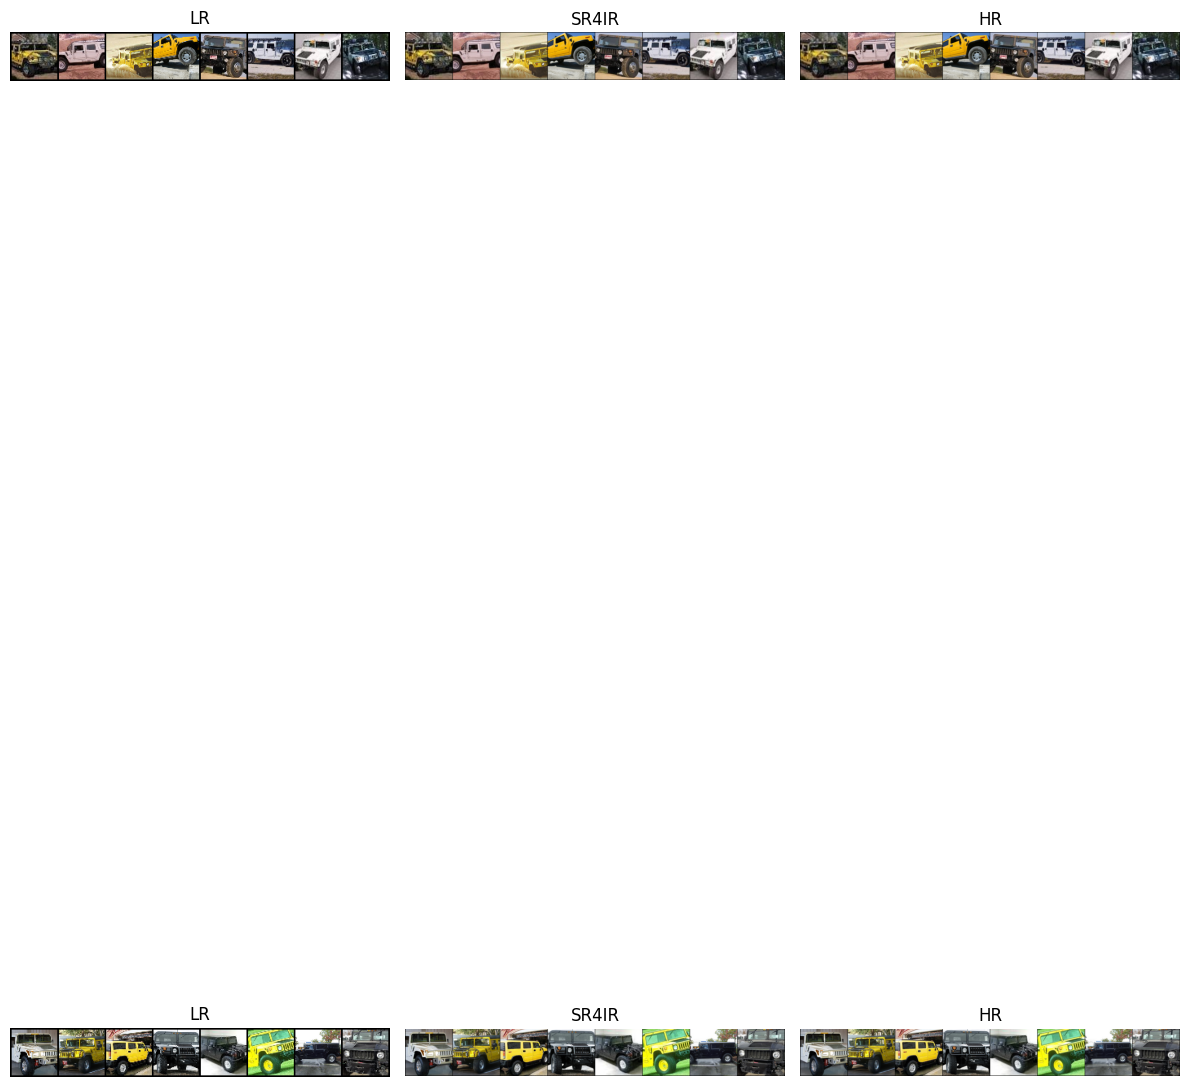

In [52]:
import matplotlib.pyplot as plt
import glob
from PIL import Image

sr_imgs = sorted(glob.glob("vis_results/*_SR.png"))

print("Total SR images saved:", len(sr_imgs))

plt.figure(figsize=(12,30))

for i, sr_path in enumerate(sr_imgs):

    lr = Image.open(sr_path.replace("_SR","_LR"))
    sr = Image.open(sr_path)
    hr = Image.open(sr_path.replace("_SR","_HR"))

    plt.subplot(len(sr_imgs),3,3*i+1)
    plt.imshow(lr)
    plt.title("LR")
    plt.axis("off")

    plt.subplot(len(sr_imgs),3,3*i+2)
    plt.imshow(sr)
    plt.title("SR4IR")
    plt.axis("off")

    plt.subplot(len(sr_imgs),3,3*i+3)
    plt.imshow(hr)
    plt.title("HR")
    plt.axis("off")

plt.tight_layout()
plt.show()

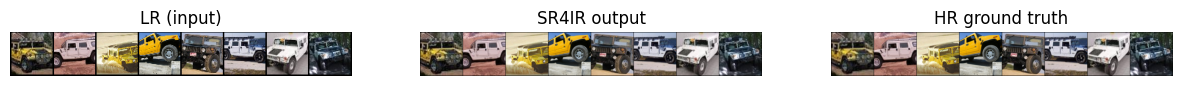

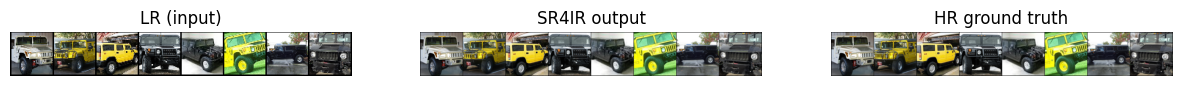

In [53]:
import matplotlib.pyplot as plt
import glob
from PIL import Image

sr_imgs = sorted(glob.glob("vis_results/*_SR.png"))

for sr_path in sr_imgs:

    lr = Image.open(sr_path.replace("_SR","_LR"))
    sr = Image.open(sr_path)
    hr = Image.open(sr_path.replace("_SR","_HR"))

    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.imshow(lr)
    plt.title("LR (input)")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(sr)
    plt.title("SR4IR output")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(hr)
    plt.title("HR ground truth")
    plt.axis("off")

    plt.show()

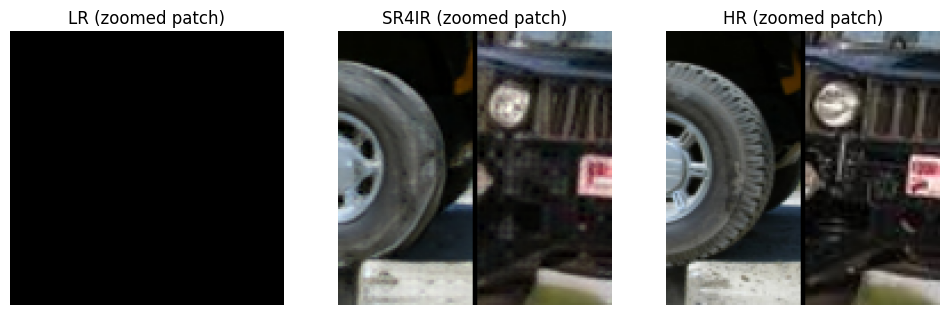

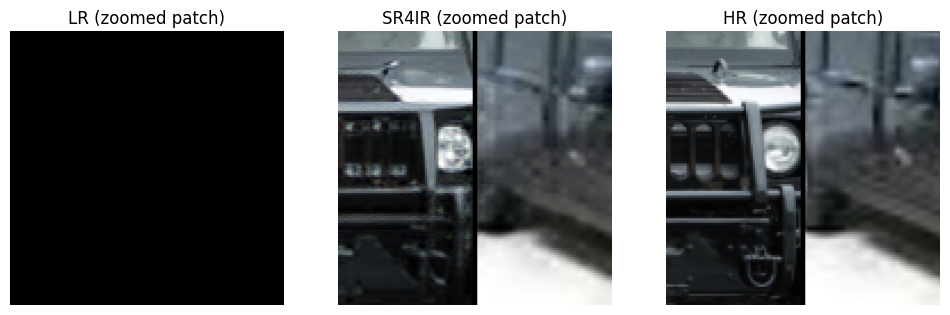

In [54]:
import matplotlib.pyplot as plt
import glob
from PIL import Image

sr_imgs = sorted(glob.glob("vis_results/*_SR.png"))

ZOOM = 4          # zoom factor
PATCH = 120       # patch size

for sr_path in sr_imgs:

    lr = Image.open(sr_path.replace("_SR","_LR"))
    sr = Image.open(sr_path)
    hr = Image.open(sr_path.replace("_SR","_HR"))

    # ---- choose center patch ----
    w, h = hr.size
    cx, cy = w//2, h//2

    box = (
        cx - PATCH//2,
        cy - PATCH//2,
        cx + PATCH//2,
        cy + PATCH//2
    )

    lr_p = lr.crop(box).resize((PATCH*ZOOM, PATCH*ZOOM), Image.NEAREST)
    sr_p = sr.crop(box).resize((PATCH*ZOOM, PATCH*ZOOM), Image.NEAREST)
    hr_p = hr.crop(box).resize((PATCH*ZOOM, PATCH*ZOOM), Image.NEAREST)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(lr_p)
    plt.title("LR (zoomed patch)")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(sr_p)
    plt.title("SR4IR (zoomed patch)")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(hr_p)
    plt.title("HR (zoomed patch)")
    plt.axis("off")

    plt.show()

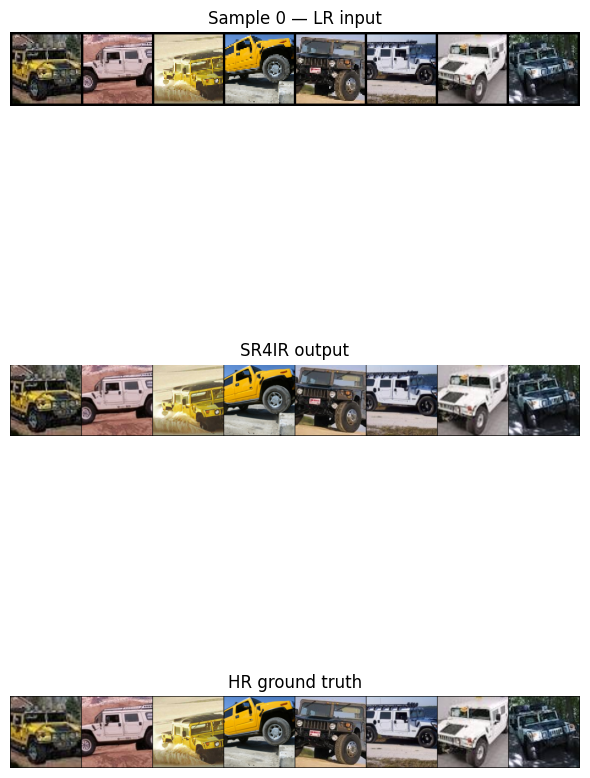

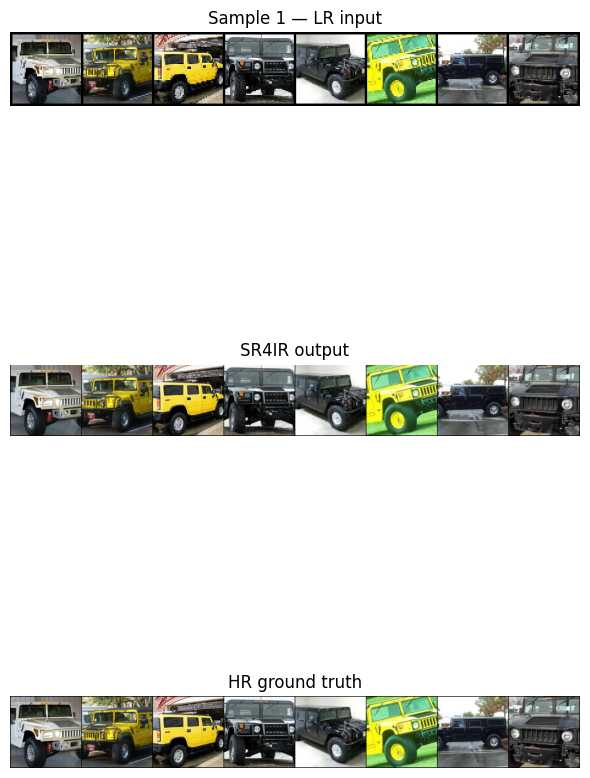

In [55]:
import matplotlib.pyplot as plt
import glob
from PIL import Image

sr_imgs = sorted(glob.glob("vis_results/*_SR.png"))

for i, sr_path in enumerate(sr_imgs):

    lr = Image.open(sr_path.replace("_SR","_LR"))
    sr = Image.open(sr_path)
    hr = Image.open(sr_path.replace("_SR","_HR"))

    plt.figure(figsize=(6,12))

    plt.subplot(3,1,1)
    plt.imshow(lr)
    plt.title(f"Sample {i} — LR input")
    plt.axis("off")

    plt.subplot(3,1,2)
    plt.imshow(sr)
    plt.title("SR4IR output")
    plt.axis("off")

    plt.subplot(3,1,3)
    plt.imshow(hr)
    plt.title("HR ground truth")
    plt.axis("off")

    plt.tight_layout()
    plt.show()